In [1]:
# ==========================================
# CELL 1: Setup & Data Loading
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv("pbp2026.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [2]:
# ==========================================
# CELL 2: Data Inspection (Algorithm 1)
# ==========================================
print("--- FIRST 5 ROWS ---")
print(df.head())

print("\n--- DATASET SHAPE ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- COLUMN DATA TYPES ---")
print(df.dtypes)

print("\n--- DATASET SUMMARY INFO ---")
df.info()

--- FIRST 5 ROWS ---
     gameid  period        clock  h_pts  a_pts team  playerid       player  \
0  22500001       1  PT12M00.00S    0.0    0.0  NaN         0          NaN   
1  22500001       1  PT12M00.00S    NaN    NaN  OKC   1631096  C. Holmgren   
2  22500001       1  PT11M36.00S    NaN    NaN  HOU   1630578    A. Sengun   
3  22500001       1  PT11M31.00S    NaN    NaN  OKC   1641717   C. Wallace   
4  22500001       1  PT11M26.00S    2.0    0.0  OKC   1631096  C. Holmgren   

          type             subtype  result      x      y  dist  \
0       period               start     NaN    0.0    0.0   0.0   
1    Jump Ball                 NaN     NaN    0.0    0.0   0.0   
2  Missed Shot           Jump Shot  Missed -179.0  179.0  25.0   
3      Rebound             Unknown     NaN    0.0    0.0   0.0   
4    Made Shot  Cutting Layup Shot    Made    0.0   13.0   1.0   

                                                desc  season  
0                  Start of 1st Period (7:44 PM ES

In [3]:
# ==========================================
# CELL 3: Data Filtering (Algorithm 2)
# ==========================================
# Filter 1: Made Shots
made_shots = df[df["result"] == "Made"]
print(f"Total Made Shots Recorded: {len(made_shots)}")

# Filter 2: Plays by OKC team with distance > 20 ft
okc_long_shots = df[(df["team"] == "OKC") & (df["dist"] > 20)]
print("OKC Long Distance Shots Sample:")
print(okc_long_shots[["player", "dist", "type", "result"]].head())

Total Made Shots Recorded: 103371
OKC Long Distance Shots Sample:
                   player  dist         type  result
20             C. Wallace  26.0  Missed Shot  Missed
24  S. Gilgeous-Alexander  25.0  Missed Shot  Missed
40            C. Holmgren  23.0    Made Shot    Made
53                L. Dort  27.0  Missed Shot  Missed
89            J. Williams  26.0  Missed Shot  Missed


Top 10 Longest Shots Recorded:
               player team  dist         type  result
508166     J. Kuminga  ATL  73.0    Made Shot    Made
59662        A. Black  ORL  64.0    Made Shot    Made
304126     M. Bridges  CHA  64.0    Made Shot    Made
125058      E. Mobley  CLE  61.0  Missed Shot  Missed
206261    B. Williams  DAL  61.0  Missed Shot  Missed
312979      J. Murray  DEN  56.0    Made Shot    Made
53991       J. Murray  DEN  56.0    Made Shot    Made
339311      C. Thomas  BKN  54.0  Missed Shot  Missed
247819  S. Fontecchio  MIA  53.0  Missed Shot  Missed
21111      D. Jenkins  DET  52.0    Made Shot    Made


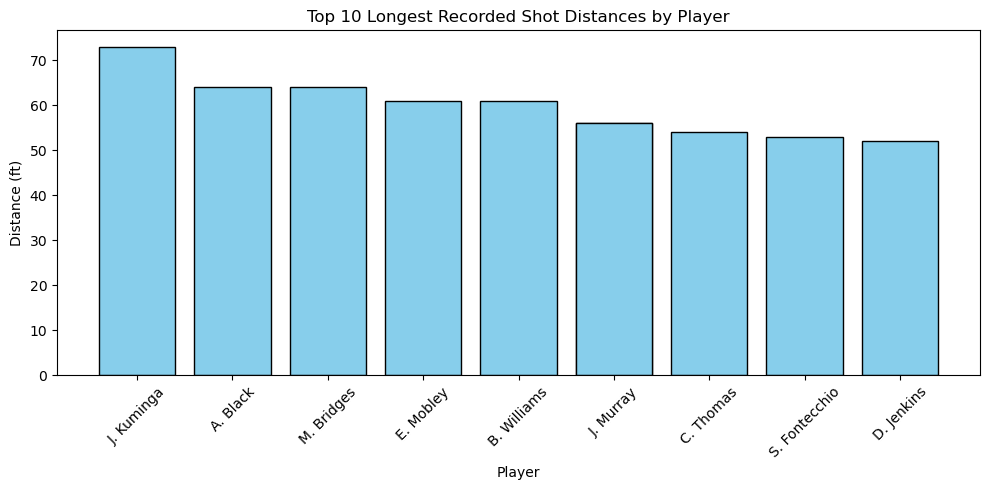

In [4]:
# ==========================================
# CELL 4: Sorting Data & Visualization (Algorithm 3)
# ==========================================
# Sort dataset by shot distance in descending order
sorted_df = df.sort_values(by="dist", ascending=False)
top_shots = sorted_df[["player", "team", "dist", "type", "result"]].head(10)
print("Top 10 Longest Shots Recorded:")
print(top_shots)

# Visualize top shot distances by player
plt.figure(figsize=(10, 5))
plt.bar(top_shots["player"], top_shots["dist"], color="skyblue", edgecolor="black")
plt.title("Top 10 Longest Recorded Shot Distances by Player")
plt.xlabel("Player")
plt.ylabel("Distance (ft)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
# ==========================================
# CELL 5: Statistical Analysis (Algorithm 4)
# ==========================================
shot_dist = df[df["dist"] > 0]["dist"]

print(f"Mean Distance: {shot_dist.mean():.2f} ft")
print(f"Median Distance: {shot_dist.median():.2f} ft")
print(f"Mode Distance: {shot_dist.mode()[0]:.2f} ft")
print(f"Standard Deviation: {shot_dist.std():.2f} ft")

print("\n--- Descriptive Statistics Summary ---")
print(df[["dist", "period", "x", "y", "h_pts", "a_pts"]].describe())

Mean Distance: 14.25 ft
Median Distance: 12.00 ft
Mode Distance: 26.00 ft
Standard Deviation: 10.43 ft

--- Descriptive Statistics Summary ---
                dist         period              x              y  \
count  620553.000000  622189.000000  620551.000000  620551.000000   
mean        4.520957       2.524849      -0.998476      33.763557   
std         8.861332       1.130129      69.168813      71.949940   
min         0.000000       1.000000    -250.000000     -51.000000   
25%         0.000000       2.000000       0.000000       0.000000   
50%         0.000000       3.000000       0.000000       0.000000   
75%         3.000000       4.000000       0.000000      17.000000   
max        73.000000       6.000000     250.000000     734.000000   

               h_pts          a_pts  
count  163415.000000  163415.000000  
mean       60.277820      59.283377  
std        35.006686      34.518722  
min         0.000000       0.000000  
25%        31.000000      30.000000  
50%    

Average Shot Distance by Top 10 Teams:
team
BOS    6.085140
PHX    5.653158
MIL    5.460924
WAS    5.344600
CHA    5.245820
GSW    5.210188
SAC    5.196538
IND    5.181414
DEN    5.166631
OKC    5.040270
Name: dist, dtype: float64


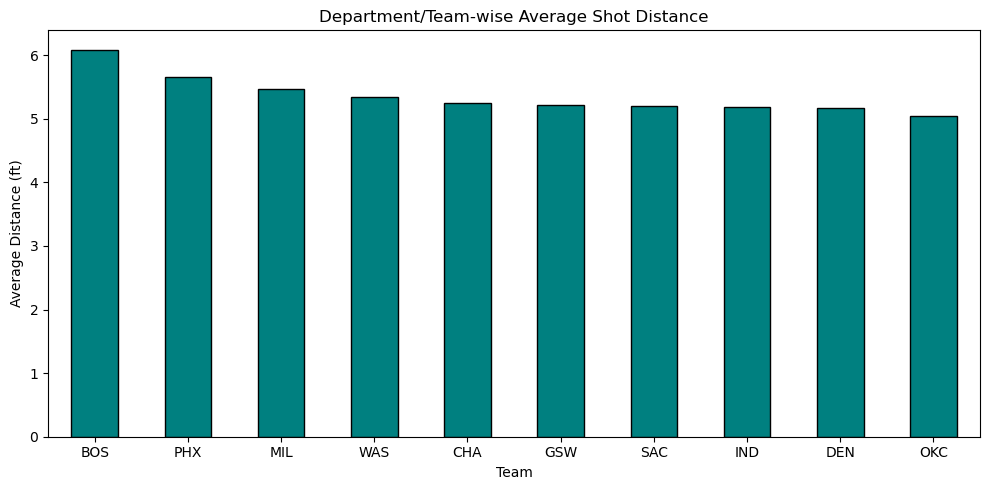

In [6]:
# ==========================================
# CELL 6: Grouping and Aggregation (Algorithm 5)
# ==========================================
# Group by Team to find average shot distance
team_avg_dist = df.groupby("team")["dist"].mean().sort_values(ascending=False).head(10)

print("Average Shot Distance by Top 10 Teams:")
print(team_avg_dist)

# Plot Grouping Result
plt.figure(figsize=(10, 5))
team_avg_dist.plot(kind="bar", color="teal", edgecolor="black")
plt.title("Department/Team-wise Average Shot Distance")
plt.xlabel("Team")
plt.ylabel("Average Distance (ft)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Correlation Matrix:
          period         x         y      dist     h_pts     a_pts
period  1.000000  0.000335 -0.020182 -0.022532  0.931422  0.932678
x       0.000335  1.000000 -0.019431 -0.028217  0.003216  0.001482
y      -0.020182 -0.019431  1.000000  0.930376 -0.042209 -0.042196
dist   -0.022532 -0.028217  0.930376  1.000000 -0.048342 -0.048473
h_pts   0.931422  0.003216 -0.042209 -0.048342  1.000000  0.937713
a_pts   0.932678  0.001482 -0.042196 -0.048473  0.937713  1.000000


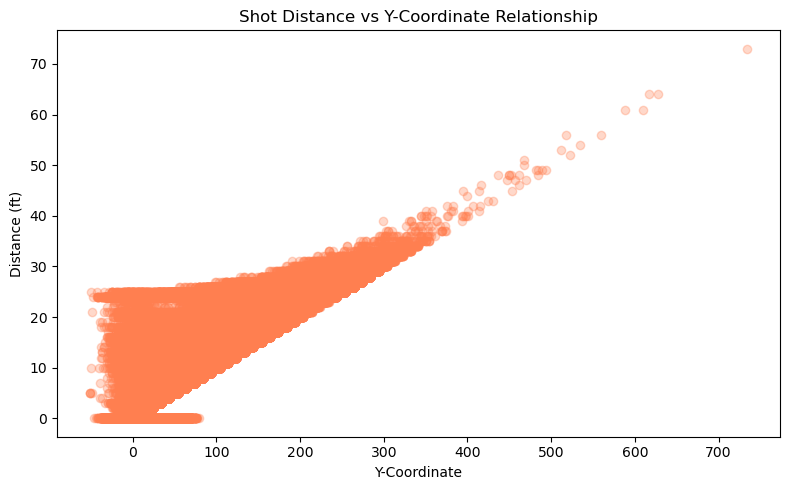

In [7]:
# ==========================================
# CELL 7: Correlation Analysis (Algorithm 6)
# ==========================================
# Calculate correlation matrix for numeric columns
num_cols = ["period", "x", "y", "dist", "h_pts", "a_pts"]
corr_matrix = df[num_cols].corr()

print("Correlation Matrix:")
print(corr_matrix)

# Visualize Correlation between Shot Distance and Y Coordinate
plt.figure(figsize=(8, 5))
plt.scatter(df["y"], df["dist"], alpha=0.3, color="coral")
plt.title("Shot Distance vs Y-Coordinate Relationship")
plt.xlabel("Y-Coordinate")
plt.ylabel("Distance (ft)")
plt.tight_layout()
plt.show()